# UK Online Retail Sales Data Analysis

## Project Overview

This notebook analyzes the UCI Online Retail dataset from a business analytics perspective. The goal is to understand revenue performance, order activity, customer behavior, and product revenue concentration for a UK-based online retailer.

The analysis focuses on descriptive business insights rather than machine learning. Key outputs include KPI summaries, monthly trend analysis, customer activity analysis, product contribution analysis, and business recommendations.

## Dataset Description

The dataset contains transaction-level online retail records from December 2010 to December 2011. Each row represents a product line within an invoice and includes invoice number, stock code, product description, quantity, invoice date, unit price, customer ID, and country.

Raw data files are stored locally only and should not be committed to GitHub. The public source is the UCI Machine Learning Repository Online Retail dataset.

## Business Questions

1. What are the main revenue, order, customer, and product KPIs after cleaning?
2. How did monthly sales, order volume, and active customer activity change over time?
3. Which products contributed the most revenue and volume?
4. How concentrated is product revenue according to Pareto-style contribution analysis?
5. What actions should the retailer prioritize based on the observed business patterns?

In [2]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

DATA_PATH = Path("../data/online_retail.xlsx")
OUTPUT_PATH = Path("../output/Online_Retail_Dashboard.xlsx")

In [3]:
df = pd.read_excel(DATA_PATH)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## Data Cleaning

The cleaning logic keeps valid sales transactions only:

- Remove records without `CustomerID` because customer-level analysis requires a customer identifier.
- Remove negative or zero `Quantity` values because they represent returns, cancellations, or invalid sales quantities.
- Remove zero or negative `UnitPrice` values because they do not represent valid paid sales.
- Convert `CustomerID` from float to integer after missing values are removed.

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
negative_quantity_count = (df["Quantity"] < 0).sum()
non_positive_price_count = (df["UnitPrice"] <= 0).sum()

print("Negative quantity records:", negative_quantity_count)
print("Non-positive unit price records:", non_positive_price_count)

Negative quantity records: 10624
Non-positive unit price records: 2517


In [9]:
df_clean = df[
    (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & (df["CustomerID"].notnull())
].copy()

df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

df_clean.shape

(397884, 8)

In [10]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Feature Engineering

Two business-facing fields are created:

- `TotalSales`: line-level revenue calculated as `Quantity * UnitPrice`.
- `InvoiceMonth`: transaction month used for monthly sales, order, and customer trends.

In [11]:
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


## KPI Summary

The cleaned dataset contains 397,884 valid transaction records from 541,909 raw transaction rows. The main portfolio KPIs are calculated below.

In [12]:
total_sales = df_clean["TotalSales"].sum()
total_orders = df_clean["InvoiceNo"].nunique()
total_customers = df_clean["CustomerID"].nunique()
total_products = df_clean["StockCode"].nunique()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Raw transaction rows",
        "Cleaned valid transaction records",
        "Total revenue",
        "Total orders",
        "Total customers",
        "Total products",
    ],
    "Value": [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        f"£{total_sales:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
    ],
})

kpi_summary

,Metric,Value
0,Raw transaction rows,"541,909"
1,Cleaned valid transaction records,"397,884"
2,Total revenue,"£8,911,407.90"
3,Total orders,"18,532"
4,Total customers,"4,338"
5,Total products,"3,665"


In [13]:
sales_by_country = (
    df_clean.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sales_by_country.head(10)

,Country,TotalSales
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


## Monthly Sales Trend

Monthly revenue increased sharply from September to November 2011 and reached its peak in November 2011. December 2011 is a partial month in the dataset, so it should not be compared directly with full months.

In [14]:
monthly_sales = (
    df_clean.groupby("InvoiceMonth")["TotalSales"]
    .sum()
    .reset_index()
)
monthly_sales["InvoiceMonth"] = monthly_sales["InvoiceMonth"].astype(str)
monthly_sales

,InvoiceMonth,TotalSales
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


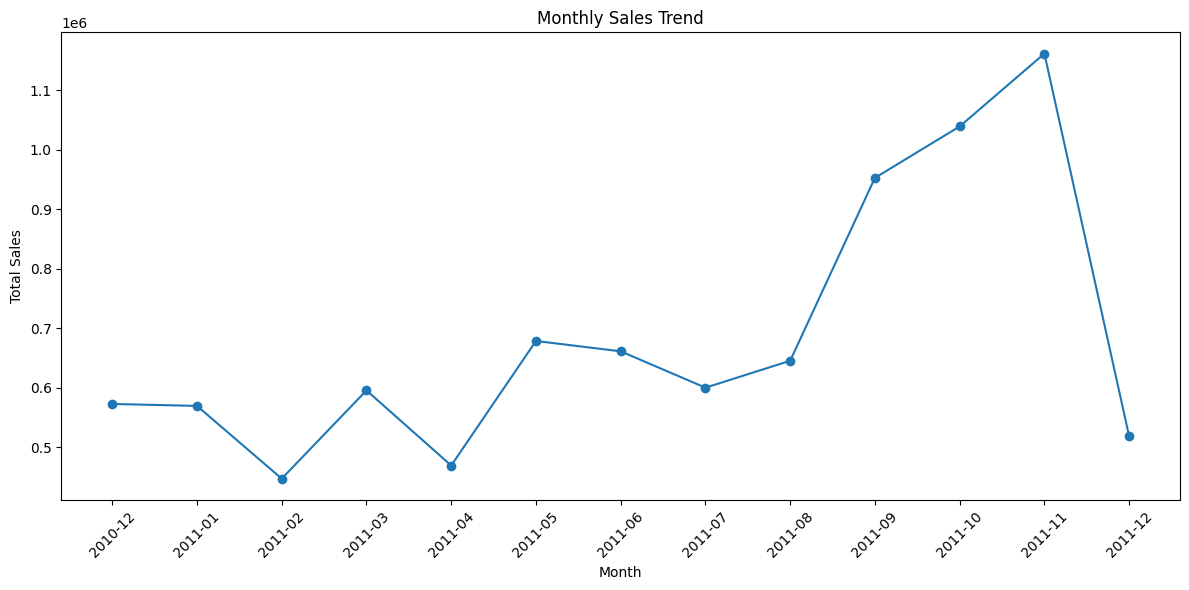

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["InvoiceMonth"], monthly_sales["TotalSales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Order Trend

Order volume followed the same upward pattern from September to November 2011. This supports the interpretation that the late-year revenue increase was driven mainly by higher order activity, not only by higher prices.

In [16]:
monthly_summary = (
    df_clean.groupby("InvoiceMonth")
    .agg(
        TotalSales=("TotalSales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
    )
    .reset_index()
)

monthly_summary["AverageOrderValue"] = monthly_summary["TotalSales"] / monthly_summary["Orders"]
monthly_summary

,InvoiceMonth,TotalSales,Orders,Customers,AverageOrderValue
0,2010-12,572713.890,1400,885,409.081350
1,2011-01,569445.040,987,741,576.945329
2,2011-02,447137.350,997,758,448.482798
3,2011-03,595500.760,1321,974,450.795428
4,2011-04,469200.361,1149,856,408.355406
5,2011-05,678594.560,1555,1056,436.395215
6,2011-06,661213.690,1393,991,474.668837
7,2011-07,600091.011,1331,949,450.857258
8,2011-08,645343.900,1280,935,504.174922
9,2011-09,952838.382,1755,1266,542.927853


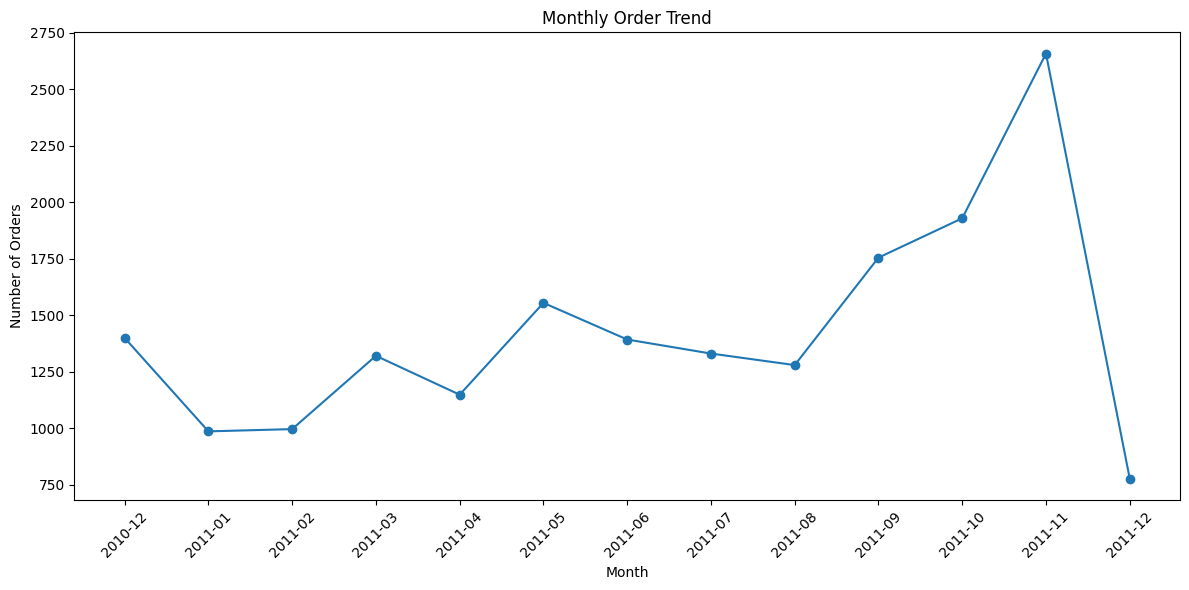

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_summary["InvoiceMonth"].astype(str), monthly_summary["Orders"], marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Customer Activity Analysis

Active customer activity increased during the same late-year period as revenue and orders. This indicates that the sales peak was supported by broader customer participation, not only by a small number of unusually large transactions.

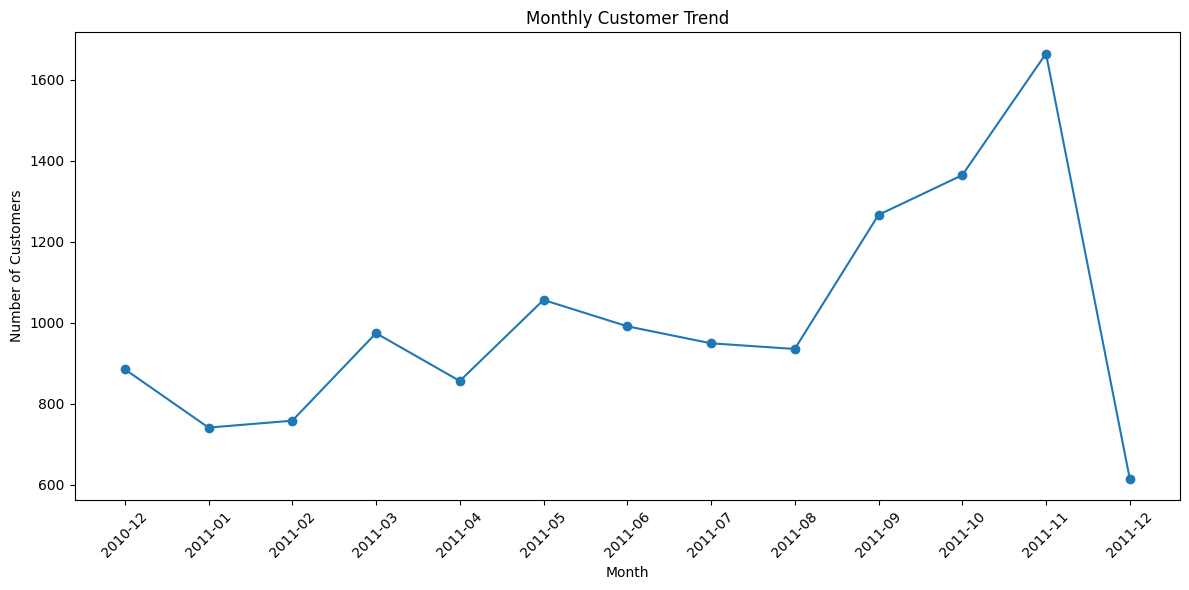

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_summary["InvoiceMonth"].astype(str), monthly_summary["Customers"], marker="o")
plt.title("Monthly Customer Trend")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
customer_summary = (
    df_clean.groupby("CustomerID")
    .agg(
        TotalSales=("TotalSales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
    )
    .reset_index()
)

customer_summary["AverageOrderValue"] = customer_summary["TotalSales"] / customer_summary["Orders"]
customer_summary = customer_summary.sort_values("TotalSales", ascending=False).reset_index(drop=True)
customer_summary.head(10)

,CustomerID,TotalSales,Orders,TotalQuantity,AverageOrderValue
0,14646,280206.02,73,196915,3838.438630
1,18102,259657.30,60,64124,4327.621667
2,17450,194550.79,46,69993,4229.365000
3,16446,168472.50,2,80997,84236.250000
4,14911,143825.06,201,80265,715.547562
5,12415,124914.53,21,77374,5948.310952
6,14156,117379.63,55,57885,2134.175091
7,17511,91062.38,31,64549,2937.496129
8,16029,81024.84,63,40208,1286.108571
9,12346,77183.60,1,74215,77183.600000


In [20]:
top_customers_by_orders = customer_summary.sort_values("Orders", ascending=False).head(10)
top_customers_by_orders

,CustomerID,TotalSales,Orders,TotalQuantity,AverageOrderValue
27,12748,33719.73,209,25747,161.338421
4,14911,143825.06,201,80265,715.547562
22,17841,40991.57,124,23071,330.577177
14,13089,58825.83,97,31070,606.451856
80,14606,12156.65,93,6224,130.716667
13,15311,60767.90,91,38194,667.779121
85,12971,11189.91,86,9289,130.115233
0,14646,280206.02,73,196915,3838.438630
8,16029,81024.84,63,40208,1286.108571
34,13408,28117.04,62,16232,453.500645


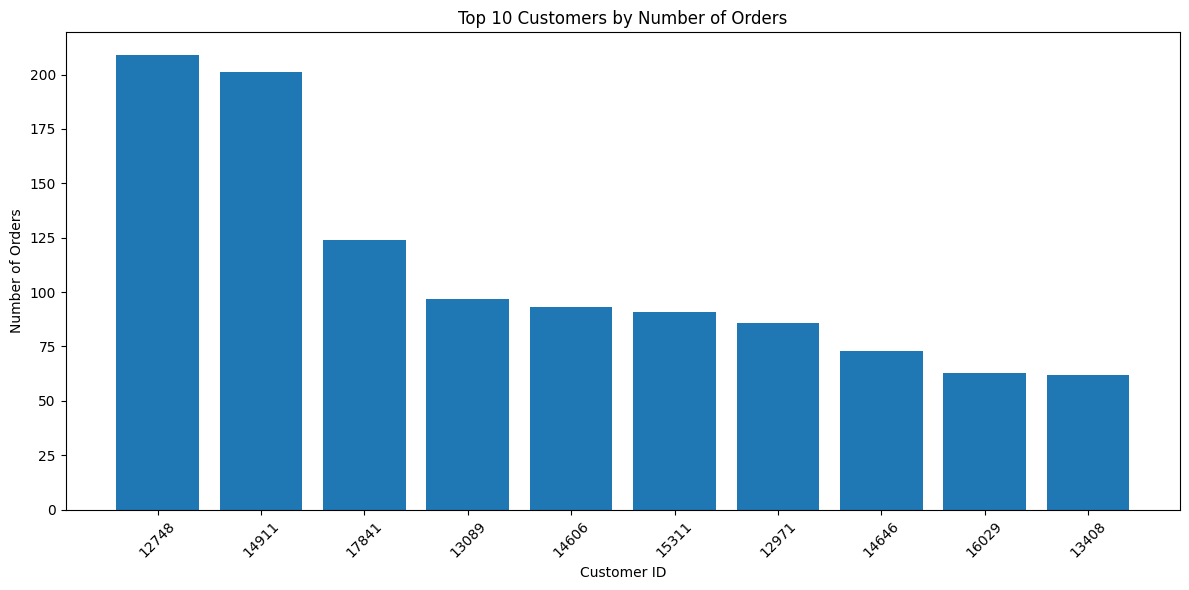

In [21]:
plt.figure(figsize=(12, 6))
plt.bar(top_customers_by_orders["CustomerID"].astype(str), top_customers_by_orders["Orders"])
plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
customer_sales_ranking = customer_summary.sort_values("TotalSales", ascending=False).reset_index(drop=True)
customer_sales_ranking["CumulativeSalesShare"] = (
    customer_sales_ranking["TotalSales"].cumsum() / customer_sales_ranking["TotalSales"].sum() * 100
)
customer_sales_ranking["CustomerRankPercent"] = (
    (range(1, len(customer_sales_ranking) + 1))
)
customer_sales_ranking["CustomerRankPercent"] = (
    customer_sales_ranking["CustomerRankPercent"] / len(customer_sales_ranking) * 100
)

customer_for_80_percent = customer_sales_ranking[
    customer_sales_ranking["CumulativeSalesShare"] >= 80
].iloc[0]

print(
    f"{customer_for_80_percent['CustomerRankPercent']:.2f}% "
    "of customers contributed 80% of total sales."
)

26.12% of customers contributed 80% of total sales.


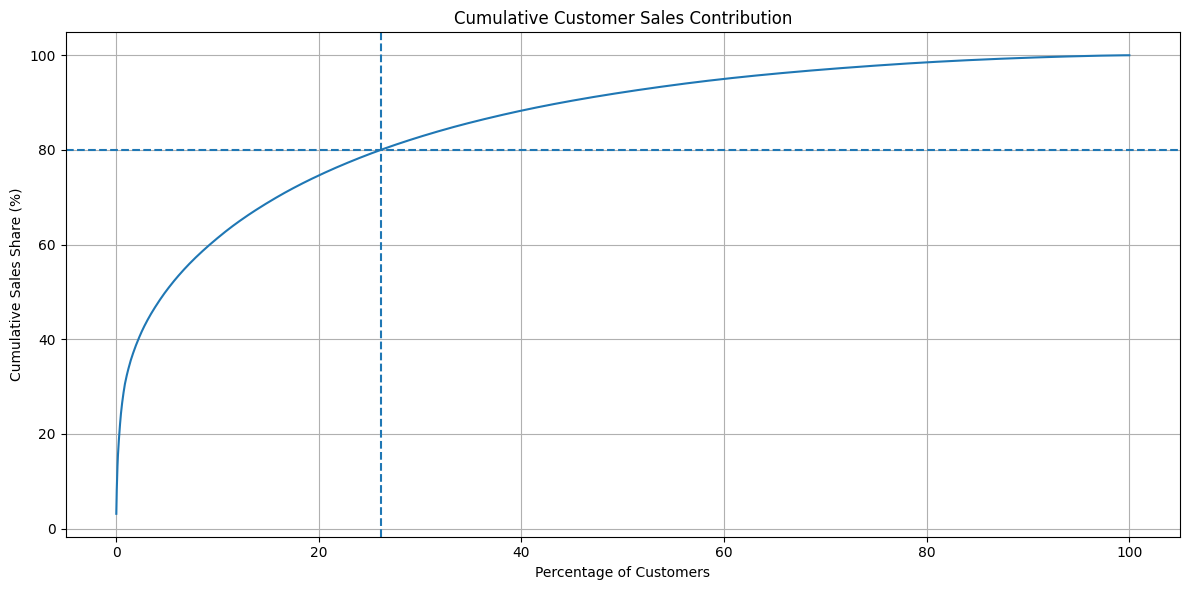

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(
    customer_sales_ranking["CustomerRankPercent"],
    customer_sales_ranking["CumulativeSalesShare"],
)
plt.axhline(y=80, linestyle="--")
plt.axvline(x=customer_for_80_percent["CustomerRankPercent"], linestyle="--")
plt.title("Cumulative Customer Sales Contribution")
plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Sales Share (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Product Contribution Analysis

The product analysis first removes administrative/service-style stock codes for product ranking charts, then uses all `StockCode` values for the KPI-level product count. This distinction matters because Pareto percentages are sensitive to how a product is defined.

In [24]:
non_product_codes = [
    "POST",
    "M",
    "D",
    "DOT",
    "BANK CHARGES",
    "AMAZONFEE",
    "CRUK",
    "C2",
    "S",
]

df_products = df_clean[~df_clean["StockCode"].astype(str).isin(non_product_codes)].copy()
df_products.shape

(396340, 10)

In [25]:
product_summary = (
    df_products.groupby("StockCode")
    .agg(
        Description=("Description", "first"),
        TotalQuantity=("Quantity", "sum"),
        TotalSales=("TotalSales", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .reset_index()
)

product_summary["AverageUnitPrice"] = product_summary["TotalSales"] / product_summary["TotalQuantity"]
product_summary.head()

,StockCode,Description,TotalQuantity,TotalSales,Orders,AverageUnitPrice
0,10002,INFLATABLE POLITICAL GLOBE,823,699.55,49,0.850000
1,10080,GROOVY CACTUS INFLATABLE,291,114.41,21,0.393162
2,10120,DOGGY RUBBER,193,40.53,29,0.210000
3,10125,MINI FUNKY DESIGN TAPES,1226,930.30,61,0.758809
4,10133,COLOURING PENCILS BROWN TUBE,2384,1143.61,122,0.479702


In [26]:
top_products_by_quantity = product_summary.sort_values("TotalQuantity", ascending=False).head(10)
top_products_by_quantity

,StockCode,Description,TotalQuantity,TotalSales,Orders,AverageUnitPrice
2329,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,2.080000
1927,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,1.044930
2499,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415,13586.25,472,0.249678
1018,22197,SMALL POPCORN HOLDER,49183,37226.43,1035,0.756896
3343,85099B,JUMBO BAG RED RETROSPOT,46181,85220.78,1600,1.845365
3349,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36782,100603.50,1978,2.735129
2602,84879,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,1375,1.600032
353,21212,PACK OF 72 RETROSPOT CAKE CASES,33693,16394.53,1029,0.486586
1849,23084,RABBIT NIGHT LIGHT,27202,51346.20,801,1.887589
1282,22492,MINI PAINT SET VINTAGE,26076,16039.24,325,0.615096


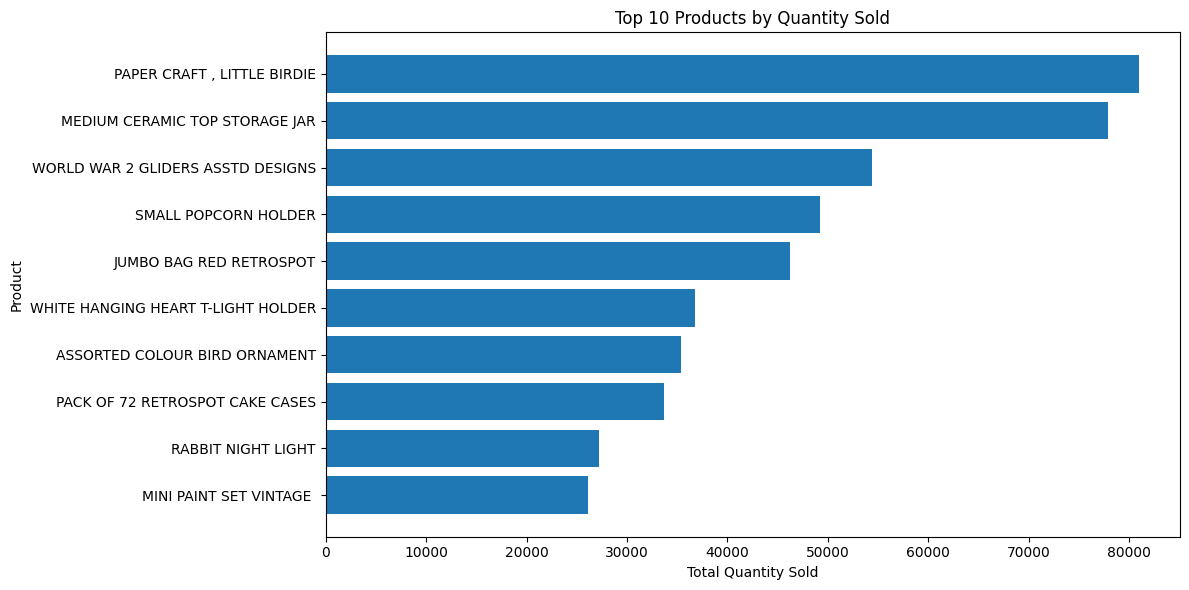

In [27]:
plt.figure(figsize=(12, 6))
plt.barh(
    top_products_by_quantity["Description"].iloc[::-1],
    top_products_by_quantity["TotalQuantity"].iloc[::-1],
)
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [28]:
top_products_by_sales = product_summary.sort_values("TotalSales", ascending=False).head(10)
top_products_by_sales

,StockCode,Description,TotalQuantity,TotalSales,Orders,AverageUnitPrice
2329,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,2.080000
1218,22423,REGENCY CAKESTAND 3 TIER,12402,142592.95,1703,11.497577
3349,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36782,100603.50,1978,2.735129
3343,85099B,JUMBO BAG RED RETROSPOT,46181,85220.78,1600,1.845365
1927,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,1.044930
2406,47566,PARTY BUNTING,15291,68844.33,1379,4.502278
2602,84879,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,1375,1.600032
1849,23084,RABBIT NIGHT LIGHT,27202,51346.20,801,1.887589
1292,22502,PICNIC BASKET WICKER SMALL,1488,47366.20,234,31.832124
2469,79321,CHILLI LIGHTS,9650,46286.51,519,4.796530


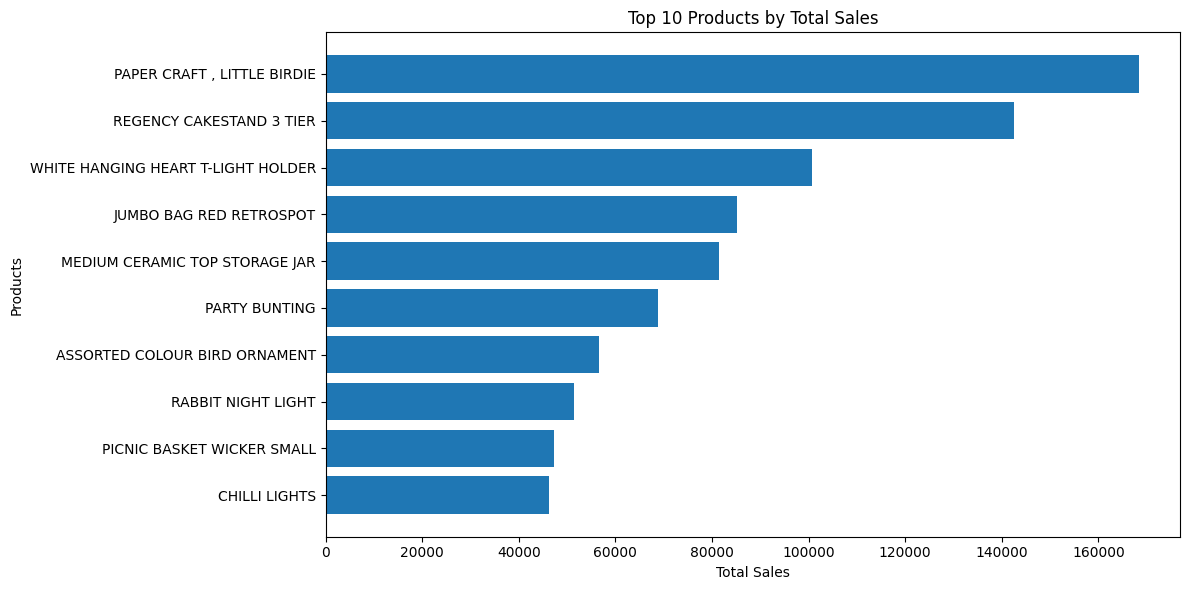

In [29]:
plt.figure(figsize=(12, 6))
plt.barh(
    top_products_by_sales["Description"].iloc[::-1],
    top_products_by_sales["TotalSales"].iloc[::-1],
)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

In [30]:
quantity_threshold = product_summary["TotalQuantity"].quantile(0.75)
price_threshold = product_summary["AverageUnitPrice"].median()

high_volume_low_price = (
    product_summary[
        (product_summary["TotalQuantity"] >= quantity_threshold)
        & (product_summary["AverageUnitPrice"] <= price_threshold)
    ]
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

high_volume_low_price

,StockCode,Description,TotalQuantity,TotalSales,Orders,AverageUnitPrice
1927,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,1.044930
2499,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415,13586.25,472,0.249678
1018,22197,SMALL POPCORN HOLDER,49183,37226.43,1035,0.756896
2602,84879,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,1375,1.600032
353,21212,PACK OF 72 RETROSPOT CAKE CASES,33693,16394.53,1029,0.486586
1282,22492,MINI PAINT SET VINTAGE,26076,16039.24,325,0.615096
1399,22616,PACK OF 12 LONDON TISSUES,25345,7266.71,382,0.286712
840,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24264,11629.70,669,0.479299
37,17003,BROCADE RING PURSE,22963,5980.05,206,0.260421
999,22178,VICTORIAN GLASS HANGING T-LIGHT,22433,28776.51,815,1.282776


In [31]:
sales_threshold = product_summary["TotalSales"].quantile(0.75)
price_threshold = product_summary["AverageUnitPrice"].quantile(0.75)

high_value_products = (
    product_summary[
        (product_summary["TotalSales"] >= sales_threshold)
        & (product_summary["AverageUnitPrice"] >= price_threshold)
    ]
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

high_value_products

,StockCode,Description,TotalQuantity,TotalSales,Orders,AverageUnitPrice
1218,22423,REGENCY CAKESTAND 3 TIER,12402,142592.95,1703,11.497577
2406,47566,PARTY BUNTING,15291,68844.33,1379,4.502278
1292,22502,PICNIC BASKET WICKER SMALL,1488,47366.20,234,31.832124
2469,79321,CHILLI LIGHTS,9650,46286.51,519,4.796530
2046,23298,SPOTTY BUNTING,7785,36173.95,1009,4.646622
2032,23284,DOORMAT KEEP CALM AND COME IN,5342,35913.85,648,6.722922
2479,82484,WOOD BLACK BOARD ANT WHITE FINISH,5921,34478.01,604,5.823005
1500,22720,SET OF 3 CAKE TINS PANTRY DESIGN,7020,33347.80,1146,4.750399
1731,22960,JAM MAKING SET WITH JARS,8151,32662.97,878,4.007235
2005,23245,SET OF 3 REGENCY CAKE TINS,5856,26625.68,718,4.546735


## Pareto Analysis

Using StockCode as the product identifier, the top 20% of products contributed 78.65% of total revenue.

Product contribution was calculated using StockCode as the product identifier. Results may vary slightly if products are grouped by Description or by StockCode-Description pairs.

In [36]:
pareto_product_summary = (
    df_clean.groupby("StockCode")
    .agg(
        TotalSales=("TotalSales", "sum"),
        TotalQuantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .reset_index()
    .sort_values("TotalSales", ascending=False)
    .reset_index(drop=True)
)

top_20_product_count = math.ceil(len(pareto_product_summary) * 0.20)
stockcode_top_20_product_share = (
    pareto_product_summary.head(top_20_product_count)["TotalSales"].sum()
    / pareto_product_summary["TotalSales"].sum()
    * 100
)

print("StockCode product count:", len(pareto_product_summary))
print("StockCode top 20% count:", top_20_product_count)
print(
    f"Using StockCode as the product identifier, the top 20% of products "
    f"contributed {stockcode_top_20_product_share:.2f}% of total revenue."
)

StockCode product count: 3665
StockCode top 20% count: 733
Using StockCode as the product identifier, the top 20% of products contributed 78.65% of total revenue.


In [33]:
pareto_product_summary["CumulativeSalesShare"] = (
    pareto_product_summary["TotalSales"].cumsum()
    / pareto_product_summary["TotalSales"].sum()
    * 100
)
pareto_product_summary["ProductRankPercent"] = (
    pd.RangeIndex(1, len(pareto_product_summary) + 1) / len(pareto_product_summary) * 100
)

product_for_80_percent = pareto_product_summary[
    pareto_product_summary["CumulativeSalesShare"] >= 80
].iloc[0]

print(
    f"{product_for_80_percent['ProductRankPercent']:.2f}% "
    "of StockCode-level products contributed 80% of total sales."
)

21.20% of StockCode-level products contributed 80% of total sales.


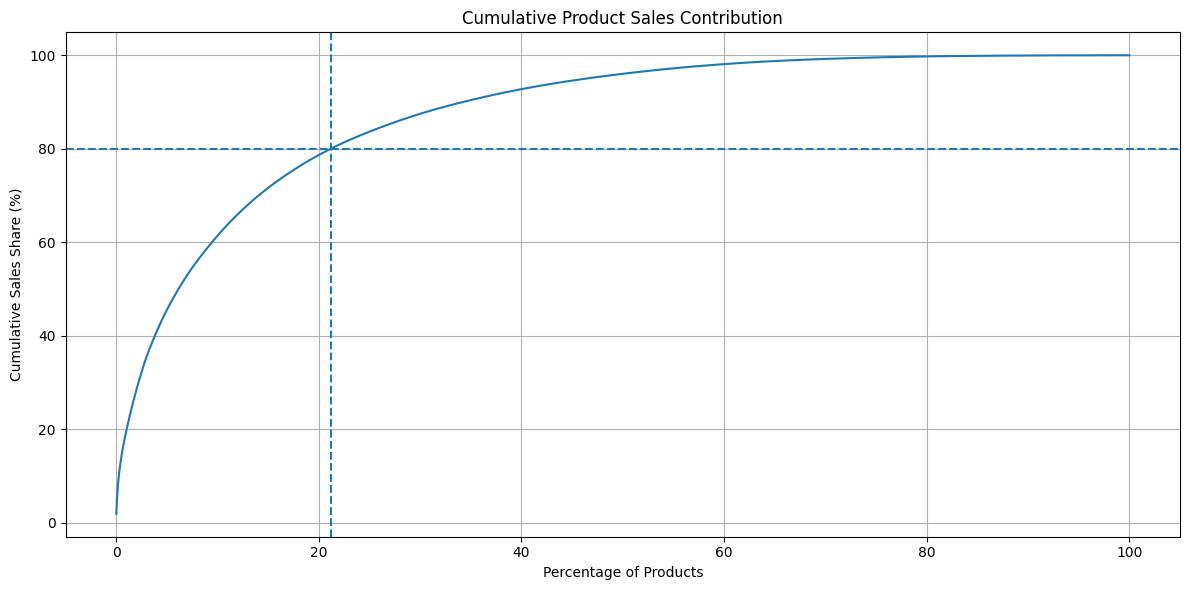

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(
    pareto_product_summary["ProductRankPercent"],
    pareto_product_summary["CumulativeSalesShare"],
)
plt.axhline(y=80, linestyle="--")
plt.axvline(x=product_for_80_percent["ProductRankPercent"], linestyle="--")
plt.title("Cumulative Product Sales Contribution")
plt.xlabel("Percentage of Products")
plt.ylabel("Cumulative Sales Share (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Business Recommendations

- Prioritize inventory planning for core products before the September to November peak season.
- Use high-volume, low-price products to support traffic, bundled offers, and repeat purchase activity.
- Protect high-value products with targeted stock monitoring because a small number of products contribute a large share of revenue.
- Plan seasonal marketing and logistics capacity before November, when sales, orders, and active customer activity reached the highest level in the cleaned data.

## Limitations and Next Steps

- December 2011 contains only partial-month data, so month-over-month comparisons with December should be interpreted carefully.
- The analysis excludes canceled, returned, missing-customer, and non-positive-price transactions; this is appropriate for sales analysis but does not analyze returns behavior.
- Product contribution was calculated using StockCode as the product identifier. Results may vary slightly if products are grouped by Description or by StockCode-Description pairs.
- Future work could add a lightweight reproducible data pipeline and a dashboard refresh script, while keeping the project focused on business analysis rather than machine learning.

In [35]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_export = df_clean.copy()
df_export["InvoiceMonth"] = df_export["InvoiceMonth"].astype(str)
df_export.to_excel(OUTPUT_PATH, index=False, engine="openpyxl")

print(f"Export complete: {OUTPUT_PATH}")
print(f"File size: {OUTPUT_PATH.stat().st_size / 1_000_000:.2f} MB")

Export complete: ../output/Online_Retail_Dashboard.xlsx
File size: 22.61 MB
